## Kmeans Clustering

In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np


In [3]:
X , y = make_blobs(n_samples=1000,centers = 3,n_features=2)

In [4]:
X , y

(array([[ 9.16246817, 10.04562881],
        [-3.62736755, -7.2131834 ],
        [ 0.33890148, -7.14895329],
        ...,
        [10.83823754,  9.2097429 ],
        [ 8.68250861, 10.37156419],
        [-2.38451306, -6.35499537]], shape=(1000, 2)),
 array([0, 2, 2, 2, 1, 0, 2, 1, 1, 0, 2, 1, 2, 1, 1, 0, 2, 0, 0, 2, 2, 1,
        2, 0, 1, 1, 1, 2, 0, 2, 0, 2, 1, 2, 1, 0, 1, 0, 2, 2, 2, 2, 2, 0,
        1, 1, 0, 2, 1, 1, 2, 2, 0, 2, 0, 2, 1, 0, 0, 0, 0, 1, 1, 2, 0, 0,
        1, 0, 2, 0, 2, 2, 0, 2, 2, 1, 2, 2, 2, 2, 2, 0, 2, 0, 1, 1, 1, 2,
        1, 1, 1, 0, 0, 0, 2, 2, 2, 0, 0, 0, 2, 0, 0, 0, 2, 0, 2, 1, 2, 1,
        1, 1, 2, 0, 2, 1, 0, 1, 0, 1, 0, 0, 1, 1, 2, 1, 1, 2, 0, 2, 1, 2,
        0, 2, 2, 2, 1, 1, 1, 2, 1, 1, 1, 0, 1, 2, 0, 2, 0, 2, 0, 2, 1, 1,
        2, 2, 1, 0, 0, 2, 1, 0, 2, 2, 2, 0, 2, 2, 0, 2, 0, 0, 2, 1, 2, 0,
        0, 1, 2, 2, 1, 2, 2, 1, 1, 2, 0, 1, 0, 1, 2, 1, 0, 2, 0, 0, 0, 2,
        1, 2, 1, 0, 1, 1, 0, 0, 1, 2, 1, 0, 1, 2, 2, 2, 2, 2, 1, 1, 1, 1,
        1, 0

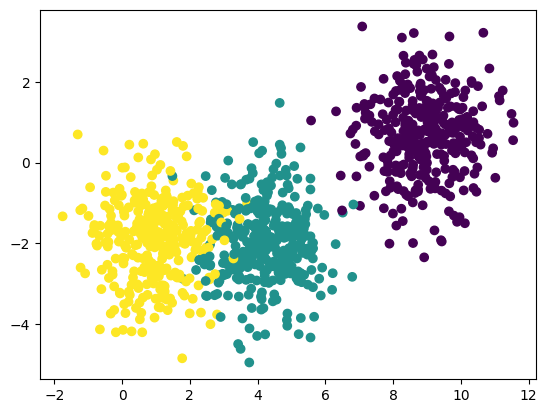

In [90]:
plt.scatter(X[:,0],X[:,1],c=y)

In [91]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X)
print(X_train_scaled)

[[-0.17258181 -1.42827155]
 [-0.61928175 -1.15794646]
 [ 1.59400751  0.53965913]
 ...
 [ 1.15188633  2.219684  ]
 [ 1.38478676  1.35053105]
 [-0.81743537  0.76908806]]


In [92]:
print(np.isnan(X_train_scaled).sum())

0


In [93]:
from sklearn.model_selection import train_test_split
X_train , X_test, y_train,y_test = train_test_split(X,y,test_size=0.33)

In [94]:
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)

In [95]:
from sklearn.cluster import KMeans

In [96]:
wcss = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

In [97]:
wcss

[420.09250421348383,
 307.3613285689784,
 252.36099965134036,
 198.31326774493016,
 147.35797347288678,
 130.3202795522582,
 122.00746456194759,
 108.75686133197085,
 95.60025955405366]

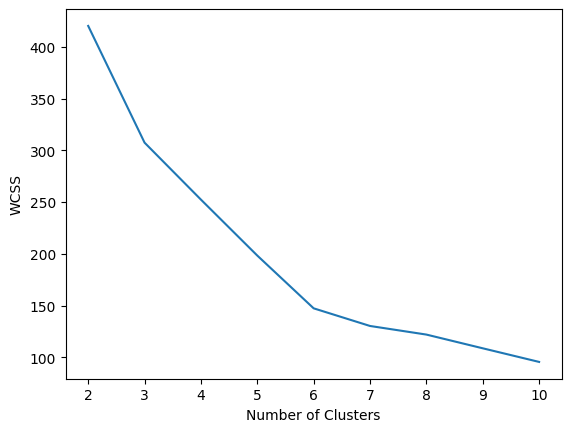

In [98]:
#elbow method
plt.plot(range(2,11),wcss)
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

## Elbow point at 3

In [99]:
kmeans = KMeans(n_clusters=3,init='k-means++')
kmeans.fit_predict(X_train_scaled)

array([0, 2, 2, 0, 0, 1, 0, 2, 1, 0, 1, 1, 0, 1, 2, 0, 2, 1, 1, 2, 1, 1,
       1, 0, 0, 2, 0, 1, 2, 1, 2, 1, 1, 0, 2, 2, 1, 0, 1, 2, 2, 1, 1, 2,
       1, 1, 2, 2, 0, 0, 1, 2, 2, 2, 1, 2, 0, 0, 2, 0, 0, 0, 2, 0, 1, 2,
       0, 2, 2, 0, 0, 1, 1, 0, 1, 2, 1, 1, 1, 1, 0, 0, 2, 0, 0, 0, 2, 0,
       0, 0, 1, 1, 1, 0, 0, 1, 2, 2, 2, 1, 1, 0, 0, 2, 0, 1, 0, 2, 0, 2,
       2, 1, 0, 2, 0, 1, 2, 0, 0, 1, 0, 1, 0, 1, 2, 1, 1, 2, 0, 1, 1, 0,
       0, 0, 0, 2, 2, 2, 0, 2, 1, 0, 2, 0, 2, 0, 0, 0, 1, 2, 0, 2, 1, 2,
       2, 0, 2, 0, 1, 1, 0, 2, 2, 1, 1, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       1, 0, 0, 0, 2, 0, 0, 2, 1, 1, 1, 0, 2, 0, 0, 0, 1, 0, 2, 2, 1, 2,
       0, 1, 2, 1, 0, 1, 0, 0, 0, 0, 0, 0, 2, 2, 1, 0, 2, 2, 1, 0, 0, 0,
       1, 0, 0, 0, 2, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 2, 0, 1, 2, 1, 1, 0,
       1, 0, 1, 0, 1, 2, 0, 0, 2, 0, 1, 2, 1, 1, 0, 1, 2, 1, 1, 1, 1, 0,
       0, 2, 0, 0, 0, 0, 2, 0, 0, 2, 0, 0, 0, 0, 2, 1, 1, 1, 1, 2, 0, 2,
       0, 1, 1, 0, 2, 0, 0, 2, 0, 0, 1, 2, 0, 1, 0,

In [100]:
y_pred = kmeans.predict(X_test_scaled)

In [101]:
y_pred

array([1, 0, 2, 0, 0, 1, 0, 1, 0, 2, 0, 1, 0, 0, 2, 0, 2, 0, 0, 1, 1, 2,
       0, 0, 0, 2, 2, 0, 0, 0, 2, 0, 1, 1, 0, 0, 2, 1, 2, 2, 2, 1, 1, 0,
       1, 1, 0, 2, 1, 2, 1, 2, 0, 1, 0, 0, 1, 0, 1, 2, 1, 2, 1, 2, 2, 0,
       2, 2, 2, 0, 1, 2, 0, 1, 1, 0, 0, 1, 1, 1, 2, 1, 1, 1, 0, 1, 2, 1,
       2, 2, 0, 2, 2, 1, 0, 1, 2, 1, 0, 0, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1,
       1, 1, 2, 0, 1, 1, 0, 0, 2, 0, 1, 0, 0, 2, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 2, 2, 1, 0, 2, 0, 1, 2, 0, 1, 0, 2, 1, 1, 2, 1, 1, 1, 2, 0, 0,
       2, 0, 2, 0, 1, 0, 0, 1, 2, 1, 1, 2, 1, 0, 2, 2, 0, 1, 1, 0, 1, 1,
       1, 2, 1, 0, 0, 0, 2, 1, 2, 2, 0, 0, 1, 2, 1, 2, 0, 1, 1, 0, 2, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 2, 0, 0, 1, 2, 0, 1, 2, 0, 0, 0, 2, 1, 1,
       1, 0, 0, 1, 2, 2, 1, 0, 2, 2, 0, 1, 1, 0, 0, 0, 0, 2, 0, 1, 2, 2,
       2, 0, 0, 0, 1, 1, 1, 2, 0, 1, 0, 1, 2, 1, 1, 2, 0, 1, 1, 1, 2, 2,
       1, 2, 2, 2, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 2, 2, 1, 2, 0, 0, 1, 1,
       2, 1, 2, 2, 0, 1, 0, 1, 2, 2, 2, 2, 2, 2, 2,

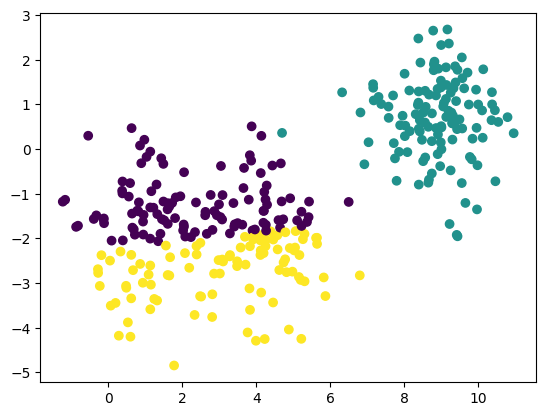

In [102]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)

In [103]:
from kneed import KneeLocator

kl = KneeLocator(range(2,11),wcss,curve="convex",direction='decreasing')
kl.elbow

np.int64(6)

In [104]:
from sklearn.metrics import silhouette_score
silhouette_coeff = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(X_train_scaled)
    score = silhouette_score(X_train_scaled,kmeans.labels_)
    silhouette_coeff.append(score)


In [105]:
silhouette_coeff

[0.6026853809290635,
 0.4339753931062674,
 0.365745921065479,
 0.3809576728145538,
 0.388217833541647,
 0.3678271055649799,
 0.36248643826180194,
 0.3525091762957731,
 0.3479542394032035]

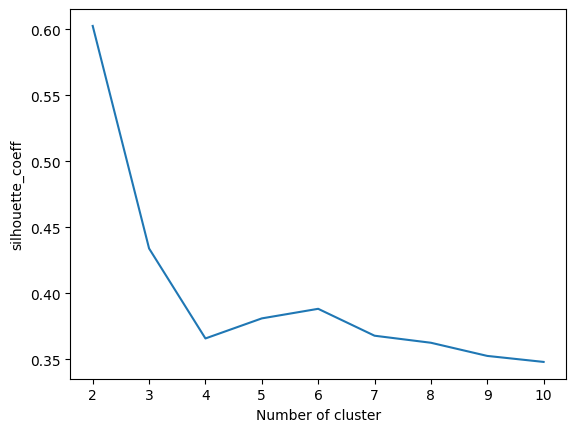

In [106]:
plt.plot(range(2,11),silhouette_coeff)
plt.xticks(np.arange(2,11,1))
plt.xlabel("Number of cluster")
plt.ylabel("silhouette_coeff")
plt.show()

## Hiearchial Clustering

In [107]:
from sklearn import datasets
iris = datasets.load_iris()
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [108]:
df = pd.DataFrame(iris.data)
df.head(10)

,0,1,2,3
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
5,5.4,3.9,1.7,0.4
6,4.6,3.4,1.4,0.3
7,5.0,3.4,1.5,0.2
8,4.4,2.9,1.4,0.2
9,4.9,3.1,1.5,0.1


In [109]:
df.columns = iris.feature_names
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [110]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)


In [111]:
X_scaled

array([[-9.00681170e-01,  1.01900435e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00, -1.31979479e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.38535265e+00,  3.28414053e-01, -1.39706395e+00,
        -1.31544430e+00],
       [-1.50652052e+00,  9.82172869e-02, -1.28338910e+00,
        -1.31544430e+00],
       [-1.02184904e+00,  1.24920112e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-5.37177559e-01,  1.93979142e+00, -1.16971425e+00,
        -1.05217993e+00],
       [-1.50652052e+00,  7.88807586e-01, -1.34022653e+00,
        -1.18381211e+00],
       [-1.02184904e+00,  7.88807586e-01, -1.28338910e+00,
        -1.31544430e+00],
       [-1.74885626e+00, -3.62176246e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00,  9.82172869e-02, -1.28338910e+00,
        -1.44707648e+00],
       [-5.37177559e-01,  1.47939788e+00, -1.28338910e+00,
        -1.31544430e+00],
       [-1.26418478e+00,  7.88807586e-01, -1.22655167e+00,
      

In [112]:
#PCA --> Reduce Dimensionality

In [113]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)# Create a PCA object that will reduce data to 2 principal components (2D)

In [114]:
pca_scaled = pca.fit_transform(X_scaled)# Fit PCA on the scaled dataset (X_scaled) and transform it into 2D reduced form

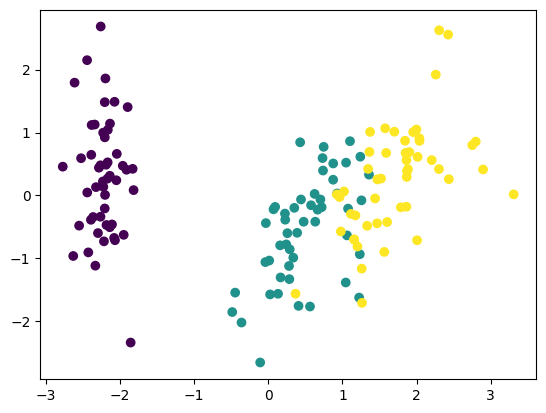

In [115]:
plt.scatter(pca_scaled[:,0],pca_scaled[:,1],c=iris.target)# Plot a scatter graph using the 2 PCA components, coloring points by iris target classes

In [116]:
import scipy.cluster.hierarchy as sc

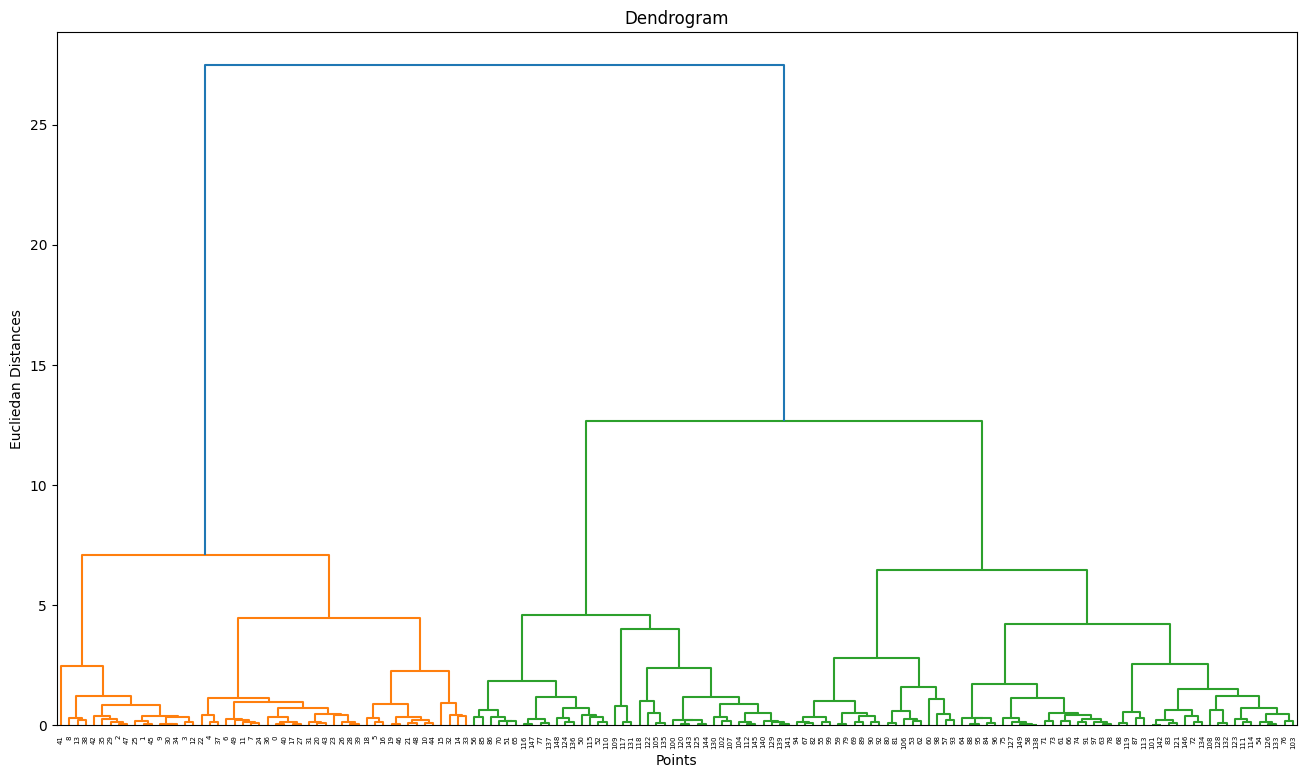

In [117]:
plt.figure(figsize=(16,9))
plt.title("Dendograms")
sc.dendrogram(sc.linkage(pca_scaled, method='ward'))
plt.title('Dendrogram')
plt.xlabel('Points')
plt.ylabel("Eucliedan Distances")
plt.show()

In [118]:
from sklearn.cluster import AgglomerativeClustering
cluster = AgglomerativeClustering(n_clusters=2,metric='euclidean',linkage='ward')
cluster.fit(pca_scaled)
cluster.labels_


array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

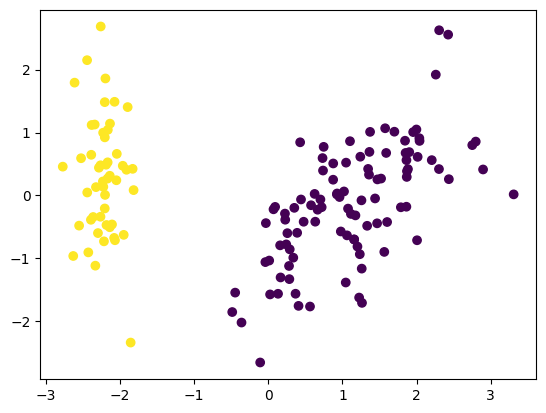

In [119]:
plt.scatter(pca_scaled[:,0],pca_scaled[:,1],c = cluster.labels_)

## DBSCAN Clustering

In [120]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons


In [121]:
X,y = make_moons(n_samples=200,noise= 0.1)

In [122]:
X , y

(array([[ 0.77092877, -0.44199149],
        [ 1.83202951, -0.31670409],
        [ 1.94438756,  0.07963665],
        [ 2.004898  ,  0.24883877],
        [-0.29552569,  0.88156915],
        [ 0.49113741,  0.89519747],
        [ 0.7225046 ,  0.80432784],
        [ 1.3063328 , -0.37323628],
        [ 0.45852578, -0.30147493],
        [ 1.14645291, -0.71684427],
        [-0.72513423,  0.79948454],
        [ 0.48629746, -0.14406561],
        [-0.90107497,  0.05662405],
        [ 0.74560113,  0.71010104],
        [-0.61463379,  0.73754419],
        [-1.08124254,  0.56003903],
        [ 2.06523701,  0.39693408],
        [ 1.80006923,  0.16826484],
        [ 0.54464708,  0.86153048],
        [ 0.95792134,  0.16105566],
        [ 1.47333952, -0.45688922],
        [-1.10977778,  0.20381814],
        [ 0.65578572, -0.49405712],
        [-0.62066934,  0.76359365],
        [ 0.10607852,  0.41532495],
        [ 0.62262982, -0.41169724],
        [ 0.07256844,  0.52868514],
        [ 0.14091531,  0.158

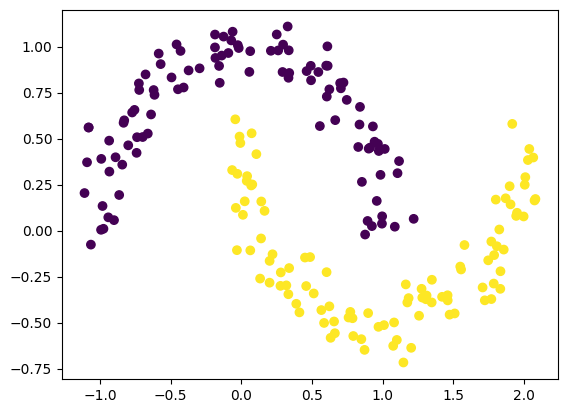

In [123]:
plt.scatter(X[:,0],X[:,1],c=y)

In [124]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


In [125]:
X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 0.31160428, -1.33699502],
       [ 1.5335892 , -1.08999665],
       [ 1.66298298, -0.30862907],
       [ 1.73266803,  0.02494514],
       [-0.91654611,  1.27234407],
       [-0.01060908,  1.29921167],
       [ 0.25583802,  1.12006637],
       [ 0.92818631, -1.20144729],
       [-0.04816528, -1.05997308],
       [ 0.74406541, -1.87885468],
       [-1.41129193,  1.11051803],
       [-0.01618286, -0.74964782],
       [-1.61390883, -0.35399735],
       [ 0.28243646,  0.93430254],
       [-1.28403741,  0.98840547],
       [-1.82139341,  0.63846218],
       [ 1.80215564,  0.31690825],
       [ 1.4967831 , -0.13390266],
       [ 0.05101373,  1.23283874],
       [ 0.52694867, -0.14811523],
       [ 1.1205146 , -1.36636523],
       [-1.85425518, -0.06381096],
       [ 0.17900322, -1.43964002],
       [-1.29098807,  1.03976077],
       [-0.45405064,  0.35316501],
       [ 0.14082022, -1.27727129],
       [-0.49264152,  0.57664944],
       [-0.41393189, -0.15391691],
       [-0.61237883,

In [126]:
dbscan = DBSCAN(eps=0.4)

In [127]:
dbscan.fit(X_scaled)

,"eps eps: float, default=0.5The maximum distance between two samples for one to be consideredas in the neighborhood of the other. This is not a maximum boundon the distances of points within a cluster. This is the mostimportant DBSCAN parameter to choose appropriately for your data setand distance function. Smaller values generally lead to more clusters.",0.4
,"min_samples min_samples: int, default=5The number of samples (or total weight) in a neighborhood for a point tobe considered as a core point. This includes the point itself. If`min_samples` is set to a higher value, DBSCAN will find denser clusters,whereas if it is set to a lower value, the found clusters will be moresparse.",5
,"metric metric: str, or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string or callable, it must be one ofthe options allowed by :func:`sklearn.metrics.pairwise_distances` forits metric parameter.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors for DBSCAN... versionadded:: 0.17 metric *precomputed* to accept precomputed sparse matrix.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 0.19",None
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'The algorithm to be used by the NearestNeighbors moduleto compute pointwise distances and find nearest neighbors.'auto' will attempt to decide the most appropriate algorithmbased on the values passed to :meth:`fit` method.See :class:`~sklearn.neighbors.NearestNeighbors` documentation fordetails.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or cKDTree. This can affect the speedof the construction and query, as well as the memory requiredto store the tree. The optimal value dependson the nature of the problem.",30
,"p p: float, default=NoneThe power of the Minkowski metric to be used to calculate distancebetween points. If None, then ``p=2`` (equivalent to the Euclideandistance). When p=1, this is equivalent to Manhattan distance.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
Name,Type,Value
"components_ components_: ndarray of shape (n_core_samples, n_features)Copy of each core sample found by training.","ndarray[float64](198, 2)","[[ 0.31,-1.34], [ 1.53,-1.09], [ 1.66,-0.31], ..., [-0.39,-0.25], [ 1.24,-0.62], [ 0.87,-1.38]]"
"core_sample_indices_ core_sample_indices_: ndarray of shape (n_core_samples,)Indices of core samples.","ndarray[int64](198,)","[ 0, 1, 2,...,197,198,199]"


In [128]:
dbscan.labels_

array([0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0,
       1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0,
       0, 0])

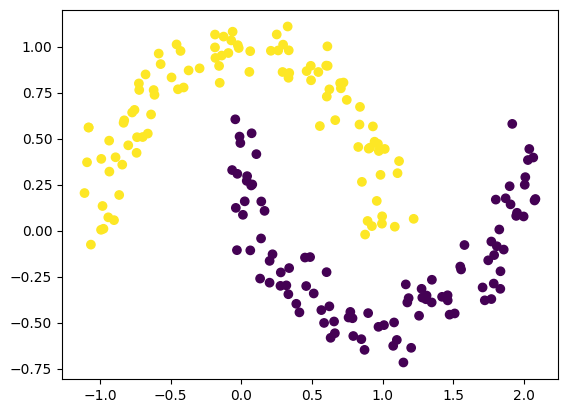

In [129]:
plt.scatter(X[:,0],X[:,1],c=dbscan.labels_)